In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

print("Setup complete!")

Setup complete!


In [ ]:
import zipfile
import os

zip_path = "/Original Images-20260908T094725Z-1-001.zip"
extract_path = "/content/banana_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

dataset_path = "/content/banana_dataset"

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 1:
        continue

banana_dataset/
  Original Images/
    Banana Bract Mosaic Virus Disease/
    Banana Black Sigatoka Disease/
    Banana Moko Disease/
    Banana Yellow Sigatoka Disease/
    Banana Insect Pest Disease/
    Banana Panama Disease/
    Banana Healthy Leaf/


In [ ]:
import os

dataset_path = "/content/banana_dataset/Original Images"

for class_name in sorted(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        image_count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
        ])

        print(f"{class_name}: {image_count} images")

Banana Black Sigatoka Disease: 67 images
Banana Bract Mosaic Virus Disease: 50 images
Banana Healthy Leaf: 86 images
Banana Insect Pest Disease: 86 images
Banana Moko Disease: 55 images
Banana Panama Disease: 41 images
Banana Yellow Sigatoka Disease: 23 images


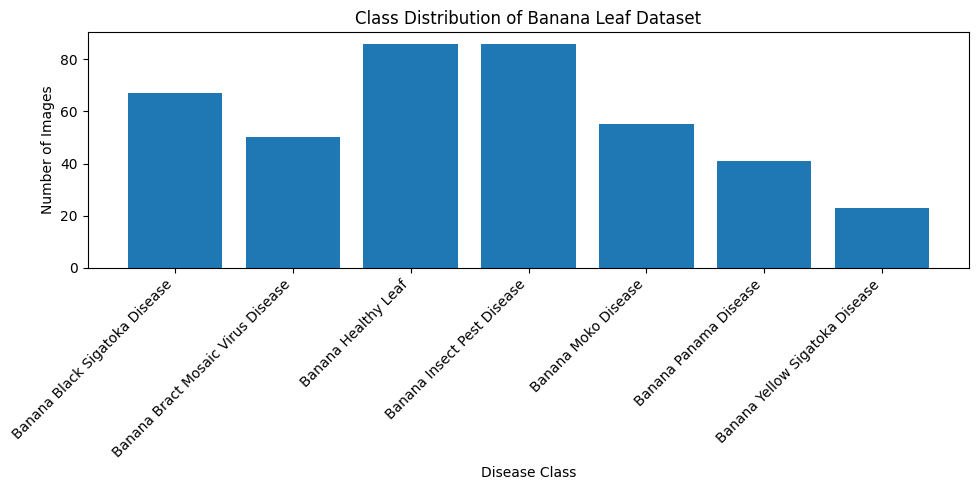

In [ ]:
import os
import matplotlib.pyplot as plt

dataset_path = "/content/banana_dataset/Original Images"

class_counts = {}

for class_name in sorted(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
        ])
        class_counts[class_name] = count

plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45, ha="right")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Banana Leaf Dataset")
plt.tight_layout()
plt.show(

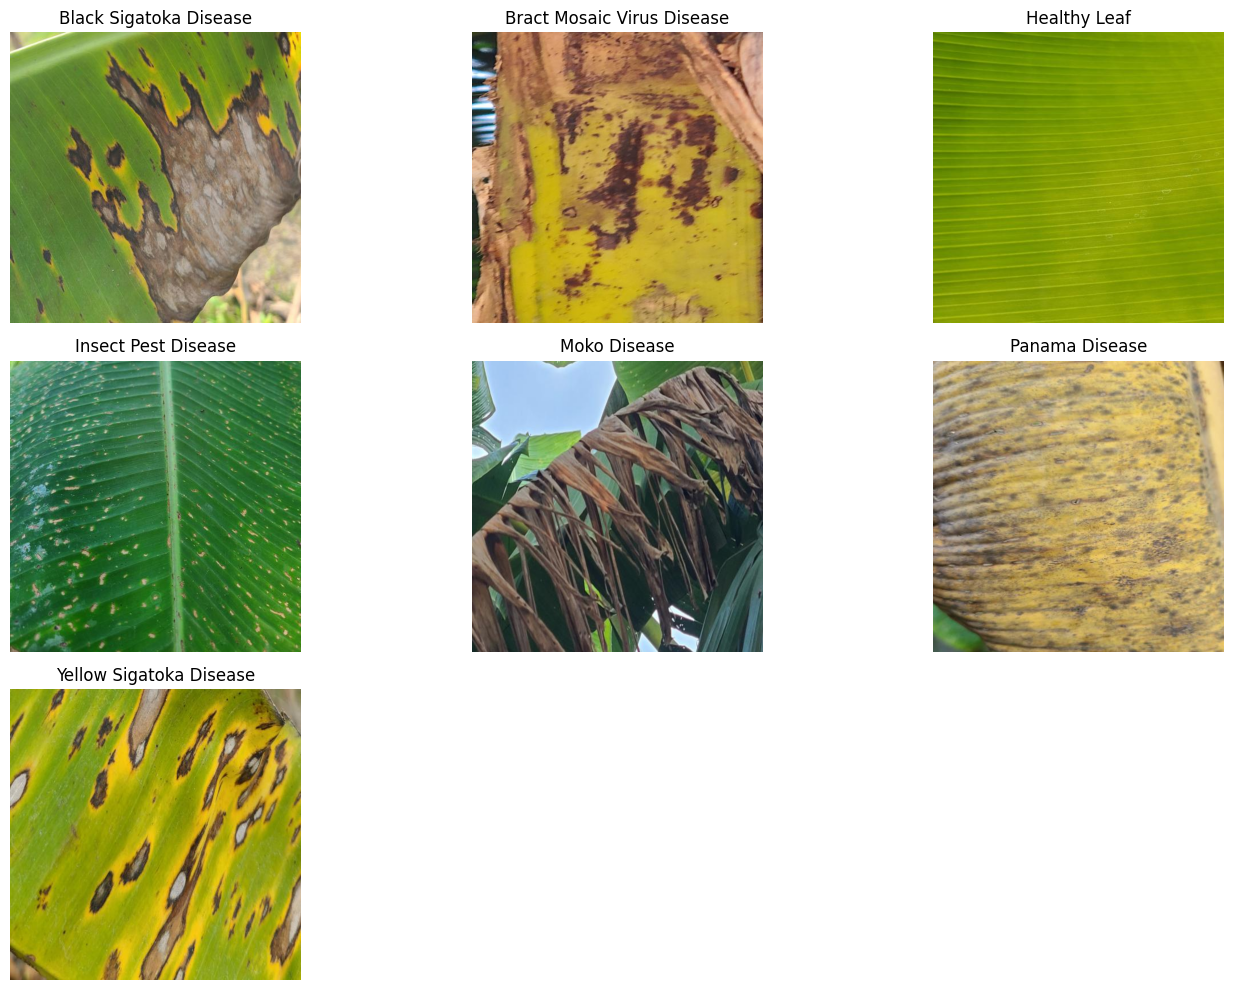

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = "/content/banana_dataset/Original Images"

classes = sorted([
    d for d in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, d))
])

plt.figure(figsize=(14, 10))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    image_file = random.choice(images)
    image_path = os.path.join(class_path, image_file)

    img = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name.replace("Banana ", ""))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter
import os
from PIL import Image

dataset_path = "/content/banana_dataset/Original Images"

sizes = []

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        for file in os.listdir(class_path):
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                try:
                    img = Image.open(os.path.join(class_path, file))
                    sizes.append(img.size)
                except:
                    pass

size_counts = Counter(sizes)

print("Total images checked:", len(sizes))
print("\nImage dimensions:")

for size, count in size_counts.most_common():
    print(size, ":", count)

Total images checked: 408

Image dimensions:
(512, 512) : 408


In [ ]:
from sklearn.model_selection import train_test_split
import os

dataset_path = "/content/banana_dataset/Original Images"

image_paths = []
labels = []

for class_name in sorted(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        for file in os.listdir(class_path):
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                image_paths.append(os.path.join(class_path, file))
                labels.append(class_name)

# 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths, labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

# Split remaining 30% into 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Test images:", len(X_test))

Training images: 285
Validation images: 61
Test images: 62


In [ ]:
from skimage.feature import hog
from skimage.io import imread
from skimage.transform import resize
import numpy as np

def extract_hog_features(image_paths):
    features = []

    for path in image_paths:
        image = imread(path)

        # Resize image
        image = resize(image, (128, 128))

        # Extract HOG features
        hog_features = hog(
            image,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            channel_axis=-1
        )

        features.append(hog_features)

    return np.array(features)

X_train_hog = extract_hog_features(X_train)
X_val_hog = extract_hog_features(X_val)
X_test_hog = extract_hog_features(X_test)

print("Training feature shape:", X_train_hog.shape)
print("Validation feature shape:", X_val_hog.shape)
print("Test feature shape:", X_test_hog.shape)

Training feature shape: (285, 8100)
Validation feature shape: (61, 8100)
Test feature shape: (62, 8100)


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Create and train SVM
svm_model = SVC(kernel="rbf", probability=True, random_state=42)

svm_model.fit(X_train_hog, y_train)

# Predict on test data
y_pred_svm = svm_model.predict(X_test_hog)

# Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Test Accuracy:", round(svm_accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Test Accuracy: 50.0 %

Classification Report:
                                   precision    recall  f1-score   support

    Banana Black Sigatoka Disease       0.33      0.10      0.15        10
Banana Bract Mosaic Virus Disease       0.67      1.00      0.80         8
              Banana Healthy Leaf       0.76      1.00      0.87        13
       Banana Insect Pest Disease       0.30      0.69      0.42        13
              Banana Moko Disease       0.00      0.00      0.00         9
            Banana Panama Disease       0.00      0.00      0.00         6
   Banana Yellow Sigatoka Disease       0.00      0.00      0.00         3

                         accuracy                           0.50        62
                        macro avg       0.29      0.40      0.32        62
                     weighted avg       0.36      0.50      0.40        62



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import tensorflow as tf
import numpy as np

class_names = sorted(set(labels))

class_to_idx = {name: i for i, name in enumerate(class_names)}

y_train_int = np.array([class_to_idx[x] for x in y_train])
y_val_int = np.array([class_to_idx[x] for x in y_val])
y_test_int = np.array([class_to_idx[x] for x in y_test])

print("Classes:")
for i, name in enumerate(class_names):
    print(i, ":", name)

Classes:
0 : Banana Black Sigatoka Disease
1 : Banana Bract Mosaic Virus Disease
2 : Banana Healthy Leaf
3 : Banana Insect Pest Disease
4 : Banana Moko Disease
5 : Banana Panama Disease
6 : Banana Yellow Sigatoka Disease


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    return image, label


train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train_int))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val_int))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test_int))

train_ds = train_ds.map(load_image).shuffle(285).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Datasets ready!")

Datasets ready!


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(7, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)

class_weights = dict(enumerate(class_weights))

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights
)

Epoch 1/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 840ms/step - accuracy: 0.4632 - loss: 1.6182 - val_accuracy: 0.7213 - val_loss: 0.8780
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 787ms/step - accuracy: 0.7684 - loss: 0.7595 - val_accuracy: 0.8689 - val_loss: 0.4844
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 687ms/step - accuracy: 0.8912 - loss: 0.4385 - val_accuracy: 0.9016 - val_loss: 0.3934
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 679ms/step - accuracy: 0.9158 - loss: 0.2885 - val_accuracy: 0.9016 - val_loss: 0.3342
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 784ms/step - accuracy: 0.9474 - loss: 0.2081 - val_accuracy: 0.8852 - val_loss: 0.2849
Epoch 6/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 650ms/step - accuracy: 0.9754 - loss: 0.1787 - val_accuracy: 0.9016 - val_loss: 0.2921
Epoch 7/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 598ms/step - accuracy: 0.9719 - loss: 0.1455 - val_accuracy: 0.9016 - val_loss: 0.2734
Epoch 8/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 650ms/step - accuracy: 0.9754 - loss: 0.1308 - val_accu

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Predict the test images
y_pred_prob = model.predict(test_ds)
y_pred_cnn = np.argmax(y_pred_prob, axis=1)

# Calculate accuracy
cnn_accuracy = accuracy_score(y_test_int, y_pred_cnn)

print("MobileNetV2 Test Accuracy:", round(cnn_accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(
    y_test_int,
    y_pred_cnn,
    target_names=class_names,
    zero_division=0
))

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 814ms/step
MobileNetV2 Test Accuracy: 90.32 %

Classification Report:
                                   precision    recall  f1-score   support

    Banana Black Sigatoka Disease       0.83      1.00      0.91        10
Banana Bract Mosaic Virus Disease       0.88      0.88      0.88         8
              Banana Healthy Leaf       1.00      1.00      1.00        13
       Banana Insect Pest Disease       1.00      0.85      0.92        13
              Banana Moko Disease       0.82      1.00      0.90         9
            Banana Panama Disease       1.00      0.67      0.80         6
   Banana Yellow Sigatoka Disease       0.67      0.67      0.67         3

                         accuracy                           0.90        62
                        macro avg       0.88      0.86      0.87        62
                     weighted avg       0.91      0.90      0.90        62



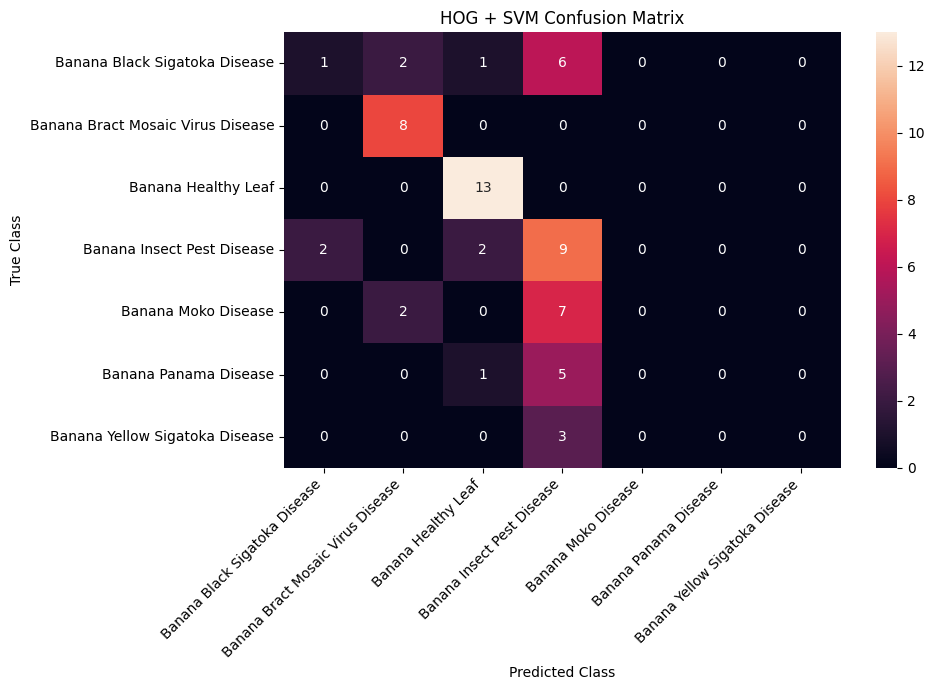

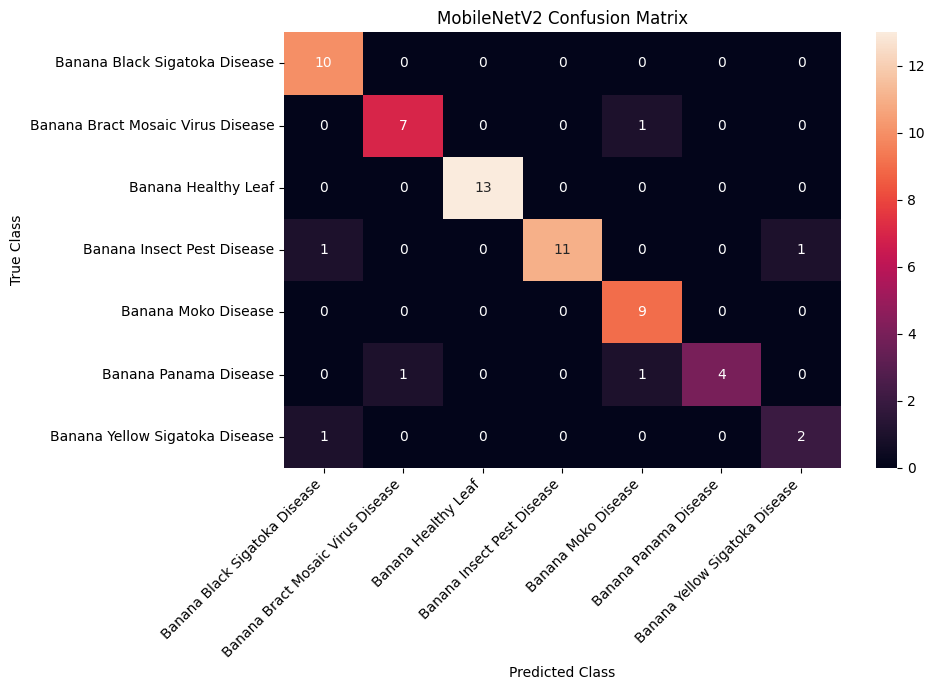

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrices
svm_cm = confusion_matrix(y_test, y_pred_svm, labels=class_names)
cnn_cm = confusion_matrix(y_test_int, y_pred_cnn)

# SVM
plt.figure(figsize=(10, 7))
sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("HOG + SVM Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# MobileNetV2
plt.figure(figsize=(10, 7))
sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

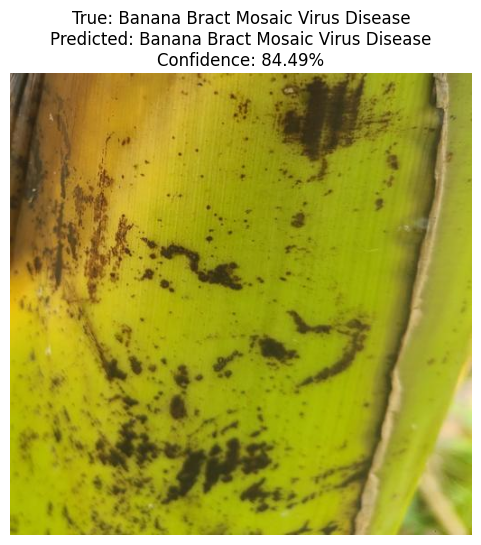

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Pick one test image
idx = 0
image_path = X_test[idx]

# Load and preprocess
image = Image.open(image_path).convert("RGB")
image_resized = image.resize((224, 224))

image_array = np.array(image_resized).astype("float32")
image_input = tf.keras.applications.mobilenet_v2.preprocess_input(image_array)
image_input = np.expand_dims(image_input, axis=0)

# Prediction
prediction = model.predict(image_input, verbose=0)[0]
predicted_idx = np.argmax(prediction)

true_class = y_test[idx]
predicted_class = class_names[predicted_idx]
confidence = prediction[predicted_idx] * 100

# Display
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"True: {true_class}\n"
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.show()